In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('toxic-comments.csv')

In [3]:
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [4]:
df.shape

(159571, 8)

In [5]:
df.columns

Index(['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate'],
      dtype='object')

In [6]:
toxicities=['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

In [7]:
comments=df.sum(numeric_only=True)
comments

,0
toxic,15294
severe_toxic,1595
obscene,8449
threat,478
insult,7877
identity_hate,1405


([<matplotlib.patches.Wedge at 0x78a44c0debd0>,
 [Text(0.2205228870492264, 1.077668620814151, 'toxic'),
  Text(-1.0627685748125797, 0.28376567162156585, 'severe_toxic'),
  Text(-0.8835448513040229, -0.655246896775675, 'obscene'),
  Text(-0.1465640005926253, -1.0901921820166778, 'threat'),
  Text(0.6339462415225215, -0.8989505897764732, 'insult'),
  Text(1.0913127724060203, -0.13797257982470842, 'identity_hate')],
 [Text(0.12028521111775985, 0.5878192477168096, '43.58%'),
  Text(-0.5796919498977706, 0.154781275429945, '4.54%'),
  Text(-0.48193355525673975, -0.35740739824127726, '24.07%'),
  Text(-0.07994400032325015, -0.594650281100006, '1.36%'),
  Text(0.34578885901228446, -0.4903366853326217, '22.44%'),
  Text(0.5952615122214656, -0.07525777081347731, '4.00%')])

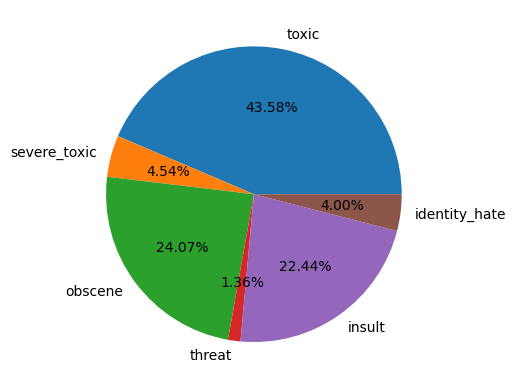

In [8]:
plt.pie(comments.values,labels=comments.index,autopct='%2.2f%%')

In [9]:
total=df.sum(numeric_only=True,axis=1)
total

,0
0,0
1,0
2,0
3,0
4,0
...,...
159566,0
159567,0
159568,0
159569,0


In [10]:
neutral=sum(total==0)
toxic=sum(total!=0)

In [11]:
neutral,toxic

(143346, 16225)

In [12]:
newdf=pd.DataFrame({
    'neutral':[sum(total==0)],
    'toxic':[sum(total!=0)],
})
newdf.shape

(1, 2)

In [13]:
newdf

,neutral,toxic
0,143346,16225


In [14]:
newsr=pd.Series([neutral,toxic],index=['neutral','toxic'])

In [15]:
newsr

,0
neutral,143346
toxic,16225


<BarContainer object of 2 artists>

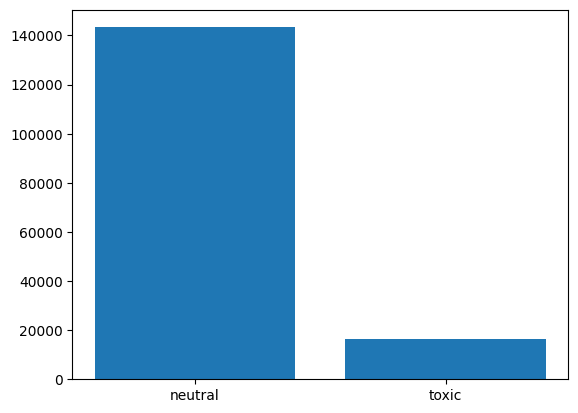

In [16]:
plt.bar(newsr.index,newsr.values)

<Axes: xlabel='None', ylabel='count'>

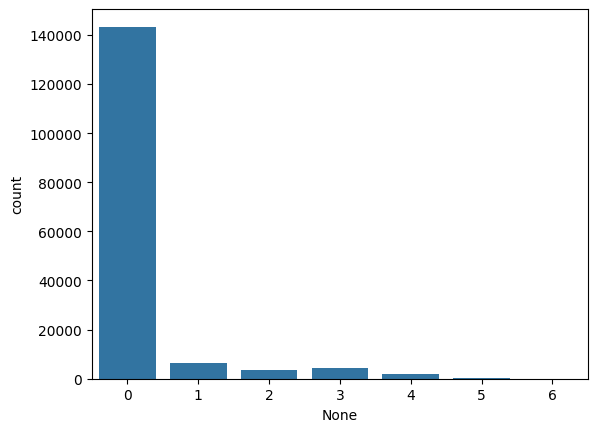

In [17]:
sns.countplot(x=total)

<Axes: xlabel='None', ylabel='count'>

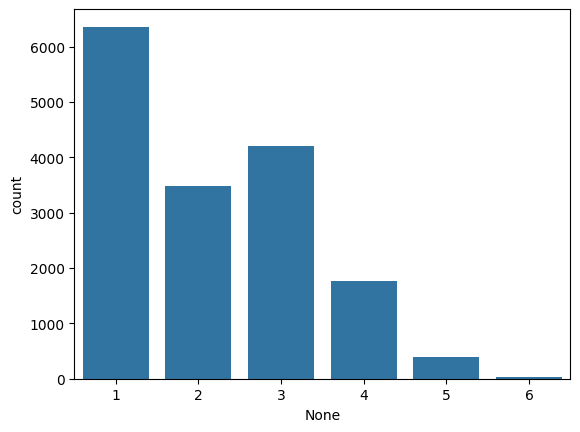

In [18]:
only_toxic=total[total!=0]
sns.countplot(x=only_toxic)

In [19]:
pd.Series(only_toxic).value_counts()

,count
1,6360
3,4209
2,3480
4,1760
5,385
6,31


In [20]:
import re

In [21]:
def clean_text(text):
    text=text.lower()
    text=re.sub('[^a-z0-9]',' ',text)
    return text

In [22]:
text='Hello! How are you?'
clean_text(text)

'hello  how are you '

In [23]:
comment_text=df['comment_text'].apply(clean_text)

In [24]:
comment_text

,comment_text
0,explanation why the edits made under my userna...
1,d aww he matches this background colour i m s...
2,hey man i m really not trying to edit war it...
3,more i can t make any real suggestions on im...
4,you sir are my hero any chance you remember...
...,...
159566,and for the second time of asking when ...
159567,you should be ashamed of yourself that is a ...
159568,spitzer umm theres no actual article for pr...
159569,and it looks like it was actually you who put ...


In [25]:
import numpy as np

In [26]:
labels=df[toxicities].values

In [27]:
labels

array([[0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       ...,
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0]])

In [28]:
#Prepare the input data
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Embedding,LSTM,Dense,GRU
from sklearn.model_selection import train_test_split

In [29]:
tokenizer=Tokenizer(num_words=5000)
tokenizer.fit_on_texts(comment_text)
sequences=tokenizer.texts_to_sequences(comment_text)
padded=pad_sequences(sequences, maxlen=200)

In [30]:
padded.shape

(159571, 200)

In [31]:
padded[0]

array([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,   

In [32]:
# Cross Validation
x_train,x_test,y_train,y_test=train_test_split(padded,labels,test_size=0.2,random_state=0)

In [33]:
x_train.shape,y_train.shape

((127656, 200), (127656, 6))

In [34]:
x_test.shape,y_test.shape

((31915, 200), (31915, 6))

In [35]:
#Build the model
model=Sequential()
model.add(Embedding(5000,100,input_length=200))
model.add(GRU(64))
model.add(Dense(6,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [36]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [37]:
#Train the model
model.fit(x_train,y_train,epochs=3,validation_data=(x_test,y_test))

Epoch 1/3
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 51s 12ms/step - accuracy: 0.9456 - loss: 0.0957 - val_accuracy: 0.9889 - val_loss: 0.0508
Epoch 2/3
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 45s 11ms/step - accuracy: 0.9888 - loss: 0.0463 - val_accuracy: 0.9780 - val_loss: 0.0484
Epoch 3/3
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 44s 11ms/step - accuracy: 0.9817 - loss: 0.0411 - val_accuracy: 0.9787 - val_loss: 0.0494


In [77]:
sample1='You are stupid. No one cares about your opinion. Just shup up.'
sample2='You are waste of time. World is better without you.'
sample3='Your life will be so beautiful with her.'
sample4='Allah-hu-Akbar'
sample5='Your mom!'
sample

In [72]:
def predict(new_comment):
  cleaned=clean_text(new_comment)
  new_seq=tokenizer.texts_to_sequences([cleaned])
  new_pad=pad_sequences(new_seq,maxlen=200)
  prediction=model.predict(new_pad)
  for i in range(len(prediction[0])):
    if prediction[0][i]>0.5:
      print(toxicities[i])

In [73]:
predict(sample1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
toxic
insult


In [74]:
predict(sample2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


In [75]:
predict(sample3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


In [76]:
predict(sample4)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


In [78]:
predict(sample5)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
toxic
